In [8]:
# Lets read the dataset
words = open('../names.txt', 'r').read().splitlines()

In [10]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [13]:
length = len(words)
maxi = max(len(word) for word in words)
mini = min(len(word) for word in words)
print(maxi, mini, length)

15 2 32033


In [ ]:
## Biagram : It is besically a technique used to predict the next character (so if first character is given then it will help to predict immediate next character)

In [40]:
# Implementing biagram manually
occurences = {}
for word in words:
    value = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(value, value[1:]):
        data = (ch1,ch2)
        occurences[data] = occurences.get(data, 0) + 1

In [41]:
occurences

{('.', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '.'): 6640,
 ('.', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('.', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('.', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('.', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('.', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '.'): 3983,
 ('.', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('.', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '.'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '.'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,
 ('g', 'a'): 330,
 ('a',

In [42]:
characters = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(characters)}
stoi['.'] = 0
stoi
itos = {i:s for s,i in stoi.items()}

In [37]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [43]:
## Create a 2d matrix to represent the occurances
mat = torch.zeros(27,27, dtype=torch.int32)

In [44]:
for data, occ in occurences.items():
    val = list(data)
    row = stoi.get(val[0])
    col = stoi.get(val[1])
    mat[row,col] = occ


In [45]:
mat

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

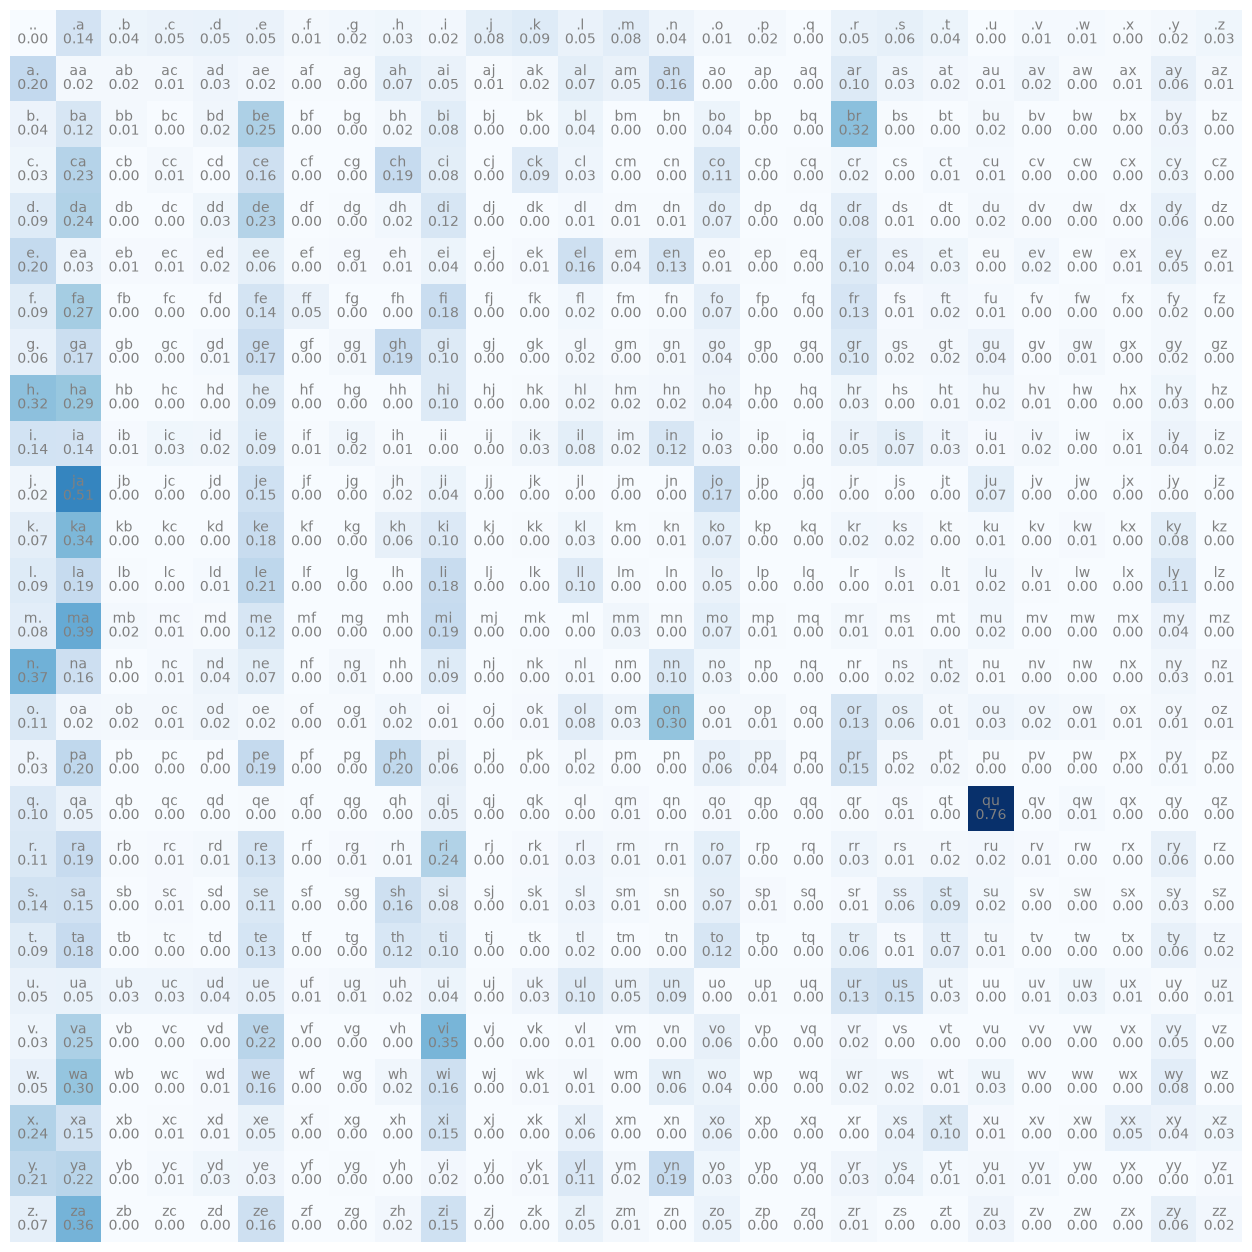

In [51]:
## Display the 2d matrix

plt.figure(figsize=(16,16))
plt.imshow(mat, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, f'{mat[i, j].item():.2f}', ha="center", va="top", color='gray')
plt.axis('off')

In [ ]:
##Above representation is fine but you look at the matrix you will notice that possibility of <S> coming at the end is 0 and same possibility/occurance of <E> coming first is 0
## because <S> can only be used at the start and <E> at the end so let normalise this 2d matrix and just use '.'

In [47]:
## Normalisation (We can do the prediction using the occurance count only but normalisation give relative preferences)
mat = mat.float()
mat /= mat.sum(dim = 1, keepdim=True)

In [68]:
## sampling to predict the next character
g = torch.Generator().manual_seed(2147483647)
for _ in range(10):
    index = 0
    word = ""

    while True:
        predictedIndex = torch.multinomial(
            mat[index],
            num_samples=1,
            generator=g
        ).item()

        character = itos[predictedIndex]
        word += character

        if predictedIndex == 0:
            break

        index = predictedIndex

    print(word)

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
